***
#  📊 Exploration Data Analysis
***

**Index**

**<span style="color:#F4E6A1;"><strong>Overview</strong></span>** 

This notebook performs the exploratory data analysis (EDA) on the processed meat consumption dataset.  
The objective is to understand the distribution of the target variable, examine relationships between meat consumption and socioeconomic indicators, and identify patterns relevant for subsequent predictive modeling.

**<span style="color:#F4E6A1;"><strong>Questions to Explore</strong></span>** 
1. What is the most consumed type of meat per country, and which one predominates globally?
2. Which countries are the highest per-capita consumers of each meat type, and how extreme are these values relative to the global distribution?
3. How has the global per capita meat consumption evolved from 2010 to 2022?
4. Which countries are in the top 5 for overall per capita meat consumption?
5. Which countries represent the modal range of global per-capita meat consumption?

**<span style="color:#F4E6A1;"><strong>Note</strong></span>** 

All data cleaning, harmonization, and missing-value handling were completed in the data processing stage.  
This notebook focuses exclusively on exploration and interpretation, not data modification.

## Initial Set up

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

## Dataset overview & sanity checks

In [3]:
# Load the master file
# This file is expected to be a CSV file containing processed meat consumption data
# The path may vary based on your directory structure
# Ensure the file exists at the specified path before running this code
# If the file is not found, you may need to adjust the path accordingly
master_file = pd.read_csv('data/processed/meat_processed_merged_cleaned_data.csv')


In [4]:
# Initial exploration of the master file

print(master_file.shape)  # Get the shape of the master file (rows, columns)
print('-----------------------')
print(list(master_file.columns))  # List the columns in the master file
print('-----------------------')
print(master_file.dtypes)  # Display the data types of each column
print('-----------------------')
print(master_file.info()) # Get a concise summary of the DataFrame
print('-----------------------')
print(master_file['Country'].nunique(), master_file['Year'].nunique())
print('-----------------------')
print( master_file.corr(numeric_only=True))  # Display the correlation matrix of the numerical columns
master_file.head(10)  # Display the first 10 rows of the master file

(1927, 9)
-----------------------
['Country', 'Year', 'Bovine Meat', 'Mutton & Goat Meat', 'Pigmeat', 'Poultry Meat', 'GDP_per_capita', 'Urban_population', 'Production']
-----------------------
Country                object
Year                    int64
Bovine Meat           float64
Mutton & Goat Meat    float64
Pigmeat               float64
Poultry Meat          float64
GDP_per_capita        float64
Urban_population      float64
Production            float64
dtype: object
-----------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1927 entries, 0 to 1926
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Country             1927 non-null   object 
 1   Year                1927 non-null   int64  
 2   Bovine Meat         1927 non-null   float64
 3   Mutton & Goat Meat  1927 non-null   float64
 4   Pigmeat             1927 non-null   float64
 5   Poultry Meat        1927 non-null   float64


,Country,Year,Bovine Meat,Mutton & Goat Meat,Pigmeat,Poultry Meat,GDP_per_capita,Urban_population,Production
0,Afghanistan,2010,4.74,5.04,0.00,2.29,560.621505,23.737,328160.00
1,Afghanistan,2011,4.80,4.66,0.00,1.92,606.694676,23.948,335664.00
2,Afghanistan,2012,4.40,5.03,0.00,2.05,651.417134,24.160,330600.00
3,Afghanistan,2013,4.18,5.20,0.00,2.11,637.087099,24.373,322110.00
4,Afghanistan,2014,4.99,5.06,0.03,2.11,625.054942,24.587,311019.70
5,Afghanistan,2015,3.81,4.77,0.02,1.96,565.569730,24.803,302781.28
6,Afghanistan,2016,3.28,4.80,0.01,2.00,522.082216,25.020,295536.47
7,Afghanistan,2017,2.92,4.45,0.02,1.79,525.469771,25.250,313220.84
8,Afghanistan,2018,2.67,4.32,0.03,1.46,491.337221,25.495,293127.78
9,Afghanistan,2019,2.76,3.45,0.04,1.81,496.602504,25.754,285593.30


## Distribution of meat consumption 

### 1. What is the most consumed type of meat per country, and which one predominates globally?

In [117]:


# Compute total meat consumption per country
meat_columns = ['Bovine Meat', 'Mutton & Goat Meat', 'Pigmeat', 'Poultry Meat']
master_file['Total_meat'] = master_file[meat_columns].sum(axis=1)

In [118]:
# Split into two dataset: one for 1010-2022 rante and the secong done for 2022 lates year

# Dataset average by country(2010–2022)


df_avg = master_file.groupby('Country')['Total_meat'].mean().reset_index().rename(columns={'Total_meat': 'avg_meat'})


# Dataset for year 2022
df_2022 = master_file[master_file['Year'] == 2022][['Country', 'Total_meat']].rename(columns={'Total_meat': 'meat_2022'})


In [119]:
# Creating different groups based on average meat consumption
df_avg['consumption_group_avg'] = pd.qcut(df_avg['avg_meat'], 5, labels=['Low', 'Medium-low', 'Medium-high', 'High', 'Extremely high'])

# Creating different groups based on meat consumption in 2022
df_2022['consumption_group_2022'] = pd.qcut(df_2022['meat_2022'], 5, labels=['Low', 'Medium-low', 'Medium-high', 'High', 'Extremely high'])


In [ ]:
# unify groups w/average consumption
master_file= master_file.merge(df_avg[['Country', 'consumption_group_avg']], on='Country', how='left')

#  unify group by 2022 consumption
master_file = master_file.merge(df_2022[['Country', 'consumption_group_2022']], on='Country', how='left')

In [121]:
master_file

,Country,Year,Bovine Meat,Mutton & Goat Meat,Pigmeat,Poultry Meat,GDP_per_capita,Urban_population,Production,Total_meat,consumption_group_avg,consumption_group_2022
0,Afghanistan,2010,4.74,5.04,0.00,2.29,560.621505,23.737,328160.0,12.07,Low,Low
1,Afghanistan,2011,4.80,4.66,0.00,1.92,606.694676,23.948,335664.0,11.38,Low,Low
2,Afghanistan,2012,4.40,5.03,0.00,2.05,651.417134,24.160,330600.0,11.48,Low,Low
3,Afghanistan,2013,4.18,5.20,0.00,2.11,637.087099,24.373,322110.0,11.49,Low,Low
4,Afghanistan,2014,4.99,5.06,0.03,2.11,625.054942,24.587,311019.7,12.19,Low,Low
...,...,...,...,...,...,...,...,...,...,...,...,...
1922,Zimbabwe,2018,40.99,1.82,0.52,4.38,2271.852504,32.209,771502.0,47.71,Medium-high,Medium-high
1923,Zimbabwe,2019,40.98,1.77,0.69,4.47,1683.913136,32.210,823826.1,47.91,Medium-high,Medium-high
1924,Zimbabwe,2020,40.12,1.76,0.64,7.21,1730.453910,32.242,821114.4,49.73,Medium-high,Medium-high
1925,Zimbabwe,2021,43.77,1.95,0.73,7.33,1724.387271,32.303,895893.5,53.78,Medium-high,Medium-high


In [122]:
df_avg['consumption_group_avg'].value_counts()

consumption_group_avg
Low               31
Medium-low        31
High              31
Extremely high    31
Medium-high       30
Name: count, dtype: int64

In [133]:
meat_means_by_group_ave = master_file.groupby('consumption_group_avg')[['Bovine Meat', 'Pigmeat', 'Poultry Meat', 'Mutton & Goat Meat']].mean()
meat_means_by_group_ave


,Bovine Meat,Pigmeat,Poultry Meat,Mutton & Goat Meat
consumption_group_avg,,,,
Low,3.428223,1.962944,3.533350,1.703858
Medium-low,8.058778,3.929651,11.021496,2.872618
Medium-high,11.178753,7.869247,24.696390,3.644545
High,13.456675,23.913553,28.052665,2.576269
Extremely high,20.762578,27.172181,36.136261,5.824844


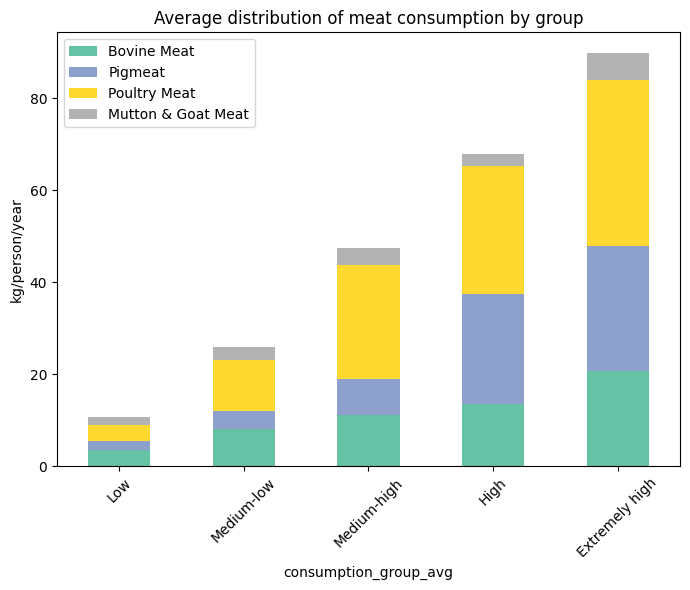

In [139]:
meat_means_by_group_ave.plot(kind='bar', stacked=True, colormap='Set2', figsize=(7,6))
plt.title('Average distribution of meat consumption by group')
plt.ylabel('kg/person/year')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Chiken meat 'Poultry Meat' predominates in all groups.

In [140]:
meat_means_by_group_2022 = master_file.groupby('consumption_group_2022')[['Bovine Meat', 'Pigmeat', 'Poultry Meat', 'Mutton & Goat Meat']].mean()
meat_means_by_group_2022

,Bovine Meat,Pigmeat,Poultry Meat,Mutton & Goat Meat
consumption_group_2022,,,,
Low,3.815198,1.886728,3.025673,1.907916
Medium-low,6.774350,4.160822,11.439523,2.660186
Medium-high,12.375538,7.522564,22.271667,3.523154
High,13.643641,24.436658,27.678832,2.313207
Extremely high,20.203399,22.650765,38.425042,6.487762


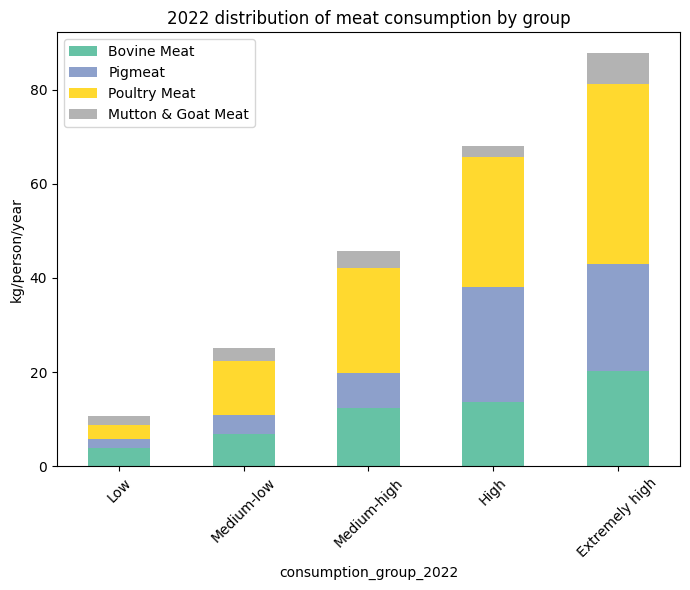

In [138]:
meat_means_by_group_2022.plot(kind='bar', stacked=True, colormap='Set2', figsize=(7,6))
plt.title('2022 distribution of meat consumption by group')
plt.ylabel('kg/person/year')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Chiken meat 'Poultry Meat' predominates in all groups, and average across time is stable, not big changes found from latrs to average data

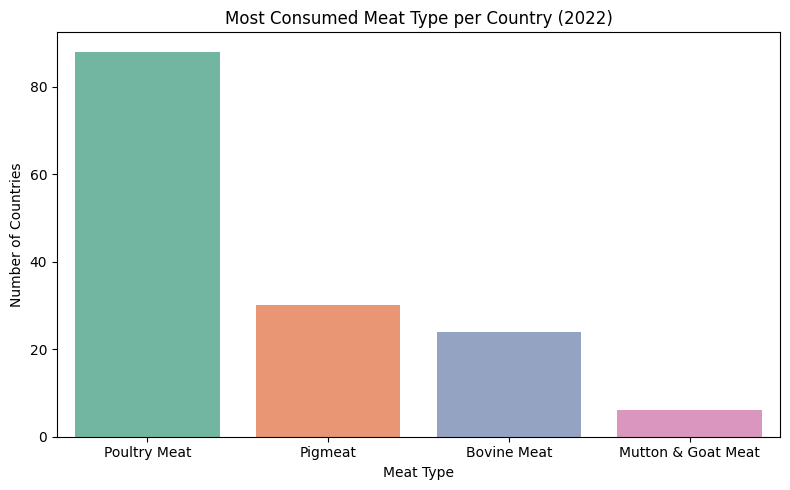

In [141]:
# 1. Select data for the year 2022
df_2022 = master_file[master_file['Year'] == 2022].copy()

# 2. Select relevant meat consumption columns
meat_columns = ['Bovine Meat', 'Mutton & Goat Meat', 'Pigmeat', 'Poultry Meat']

# 3. Identify the most consumed meat type per country
df_2022['most_consumed_meat'] = df_2022[meat_columns].idxmax(axis=1)

# 4. Visualize the distribution of dominant meat types


plt.figure(figsize=(8, 5))
sns.countplot(
    data=df_2022,
    x='most_consumed_meat',
    order=df_2022['most_consumed_meat'].value_counts().index,
    palette='Set2'
)
plt.title("Most Consumed Meat Type per Country (2022)")
plt.xlabel("Meat Type")
plt.ylabel("Number of Countries")
plt.tight_layout()
plt.show()


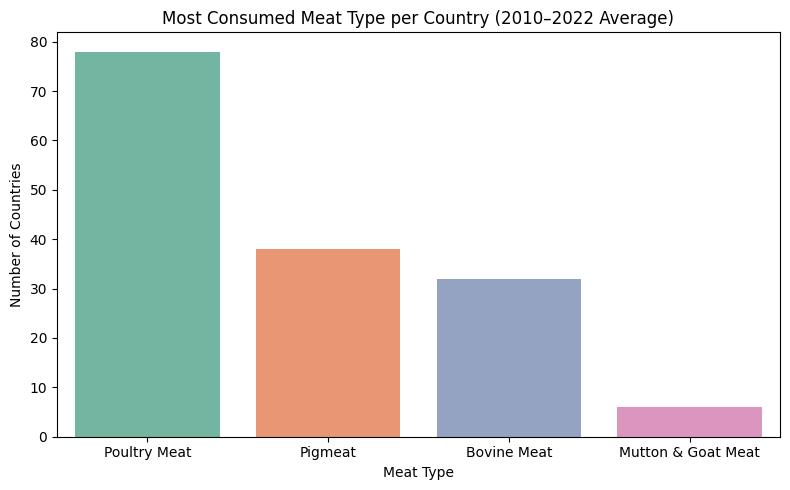

In [142]:
# Group by country and compute average consumption per meat type
avg_meat_by_country = master_file.groupby('Country')[meat_columns].mean().reset_index()

# Identify the meat type with highest average consumption per country
avg_meat_by_country['most_consumed_meat_avg'] = avg_meat_by_country[meat_columns].idxmax(axis=1)

# Plot the distribution of dominant meat types (average)
plt.figure(figsize=(8, 5))
sns.countplot(
    data=avg_meat_by_country,
    x='most_consumed_meat_avg',
    order=avg_meat_by_country['most_consumed_meat_avg'].value_counts().index,
    palette='Set2'
)
plt.title("Most Consumed Meat Type per Country (2010–2022 Average)")
plt.xlabel("Meat Type")
plt.ylabel("Number of Countries")
plt.tight_layout()
plt.show()


#### Answer to Q1 - Summary

In [153]:
# Creat the total meat  
master_file['Total_meat'] = (
    master_file['Bovine Meat'] +
    master_file['Pigmeat'] +
    master_file['Poultry Meat'] +
    master_file['Mutton & Goat Meat']
)


In [147]:
df_2022 = master_file[master_file['Year'] == 2022][['Country', 'Total_meat']].rename(columns={'Total_meat': 'meat_2022'})


In [150]:
top_5 = df_2022.sort_values(by='meat_2022', ascending=False).head(5)
bottom_5 = df_2022.sort_values(by='meat_2022', ascending=True).head(5)

print(" Top 5 meat-consuming countries in 2022 (kg/person/year):")
print(top_5[['Country', 'meat_2022']])

print("\n Bottom 5 meat-consuming countries in 2022 (kg/person/year):")
print(bottom_5[['Country', 'meat_2022']])


 Top 5 meat-consuming countries in 2022 (kg/person/year):
        Country  meat_2022
1779      Tonga     147.51
878      Israel     113.18
77    Argentina     112.08
103   Australia     111.40
1197   Mongolia     108.47

 Bottom 5 meat-consuming countries in 2022 (kg/person/year):
         Country  meat_2022
290      Burundi       3.63
146   Bangladesh       4.25
1517      Rwanda       4.97
1080  Madagascar       5.21
1331       Niger       5.25


**<span style="color:#F4E6A1;"><strong>Note</strong></span>**  
The country-level top and bottom rankings are shown for descriptive context and scale reference.  
They are not used to infer global dominance patterns, which are assessed using aggregated distributions.

**<span style="color:#F4E6A1;"><strong>Summary</strong></span>**

Across all consumption groups and time periods considered, poultry meat is the most widely consumed meat type and the dominant component of total per capita meat consumption. This pattern holds both in the 2010–2022 average and in the most recent year (2022), and is observed across the majority of countries.

Pigmeat and bovine meat dominate consumption only in a smaller subset of countries, while mutton and goat meat remains marginal in most cases.


### 2. Which countries are the highest per-capita consumers of each meat type, and how extreme are these values relative to the global distribution?

In [8]:
#the columns in this dataset are:
print(master_file.columns)

Index(['Country', 'Year', 'Bovine Meat', 'Mutton & Goat Meat', 'Pigmeat',
       'Poultry Meat', 'GDP_per_capita', 'Urban_population', 'Production'],
      dtype='object')


In [9]:
## Step 1: Group by 'country' and calculate average consumption per meat type
meat_columns = ['Bovine Meat', 'Mutton & Goat Meat', 'Pigmeat', 'Poultry Meat']
meat_means_by_country = master_file.groupby('Country')[meat_columns].mean().reset_index()
# checking columns and final set
print(meat_columns)
print(meat_means_by_country.head())

['Bovine Meat', 'Mutton & Goat Meat', 'Pigmeat', 'Poultry Meat']
               Country  Bovine Meat  Mutton & Goat Meat   Pigmeat  \
0          Afghanistan     3.540000            4.477692  0.018462   
1              Albania    14.103077            8.603846  7.674615   
2              Algeria     5.132308            7.866923  0.004615   
3               Angola     5.030000            0.823077  7.703077   
4  Antigua and Barbuda    10.121538            1.650000  8.490769   

   Poultry Meat  
0      1.809231  
1     13.644615  
2      7.010000  
3     11.203077  
4     65.926923  


In [ ]:
# Step 2: For each meat type, order countries by average per capita consumption and extract top 10

for meat in meat_columns:
    top_10_countries = (
    meat_means_by_country[['Country', meat]]
    .sort_values(by=meat, ascending=False)
    .head(10)
    .reset_index(drop=True)
)

    print(f"\nTop 10 countries for {meat} consumption (kg/person/year):")
    print(top_10_countries)


Top 10 countries for Bovine Meat consumption (kg/person/year):
            Country  Bovine Meat
0         Argentina    50.339231
1          Zimbabwe    45.130000
2            Brazil    37.229231
3         Australia    32.810769
4  French Polynesia    30.770769
5            Israel    30.540000
6        Luxembourg    29.091538
7        Uzbekistan    28.096154
8            Canada    28.056923
9           Uruguay    27.106923

Top 10 countries for Mutton & Goat Meat consumption (kg/person/year):
        Country  Mutton & Goat Meat
0      Mongolia           53.604615
1       Bahrain           22.390000
2  Turkmenistan           21.474615
3       Iceland           20.380769
4   New Zealand           16.686923
5          Chad           15.526154
6         Tonga           15.232500
7        Kuwait           13.506154
8         Qatar           12.852500
9    Mauritania           12.786923

Top 10 countries for Pigmeat consumption (kg/person/year):
      Country    Pigmeat
0      Poland  52.701

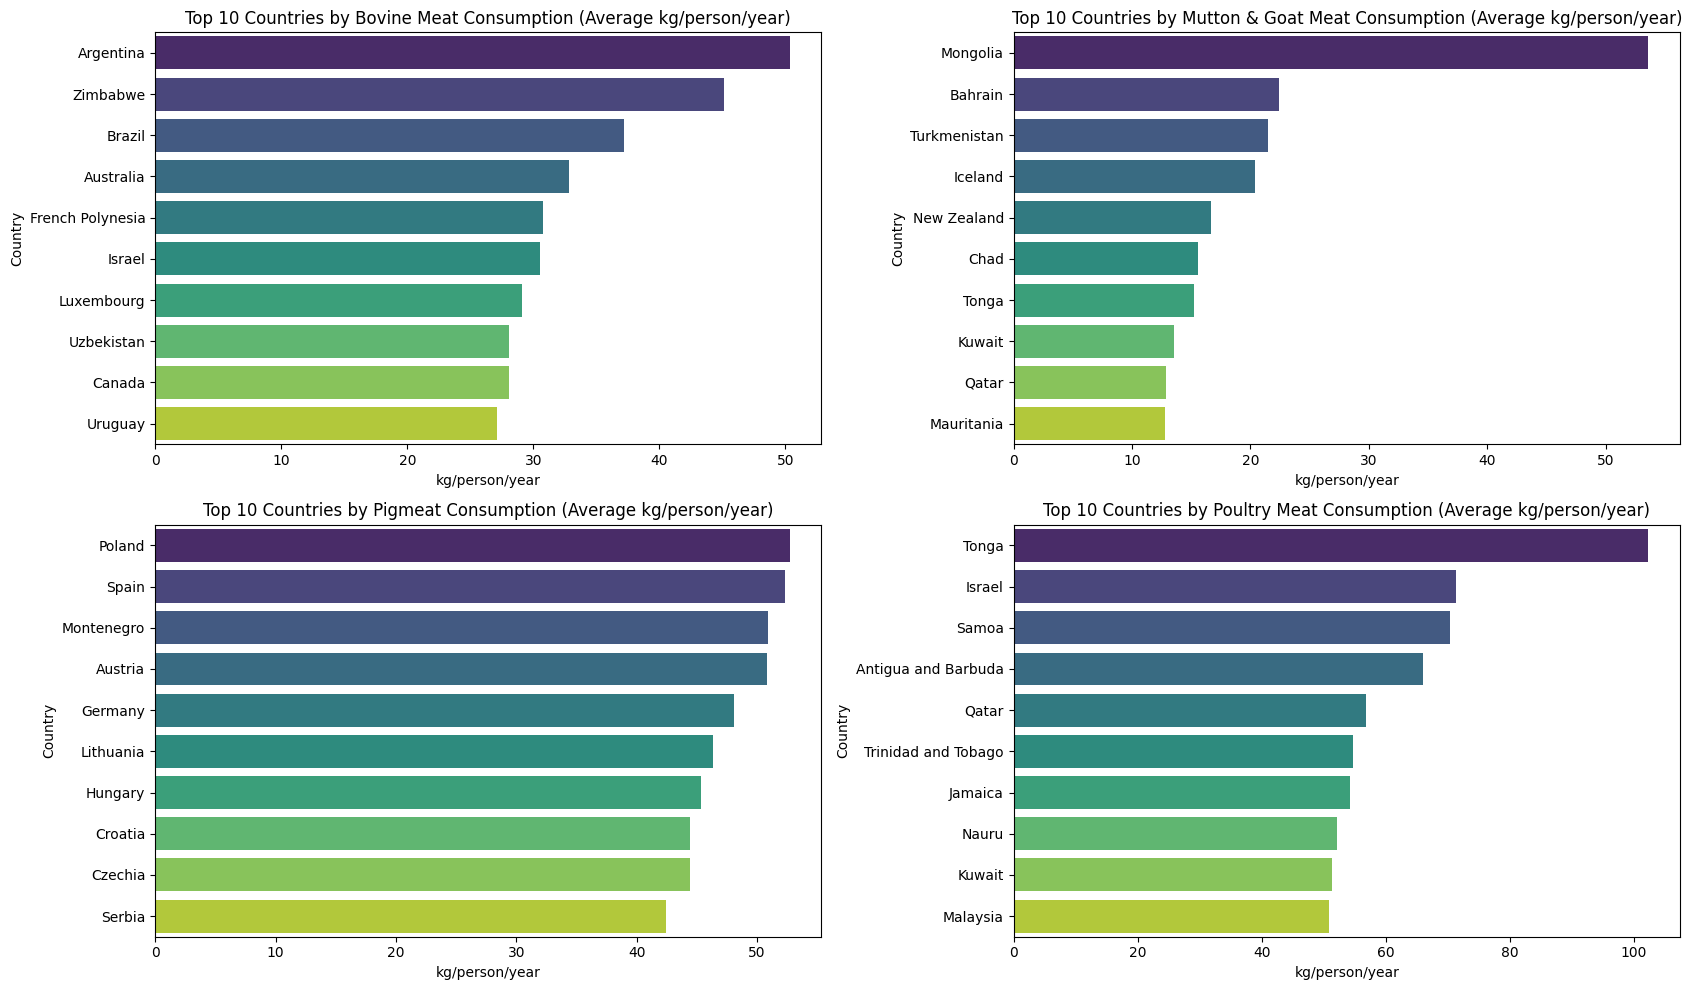

In [28]:
# Comparing top 10 countries per meat type with bar plots
# all plots in one figure with 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(17, 10))   
for ax, meat in zip(axes.flatten(), meat_columns):  
    top_10_countries = (
        meat_means_by_country[['Country', meat]]
        .sort_values(by=meat, ascending=False)
        .head(10)
        .reset_index(drop=True)
    )
    
    sns.barplot(
        data=top_10_countries,
        x=meat,
        y='Country',
        palette='viridis',
        ax=ax
    )
    ax.set_title(f"Top 10 Countries by {meat} Consumption (Average kg/person/year)")
    ax.set_xlabel("kg/person/year")
    ax.set_ylabel("Country")
plt.tight_layout()
plt.show()

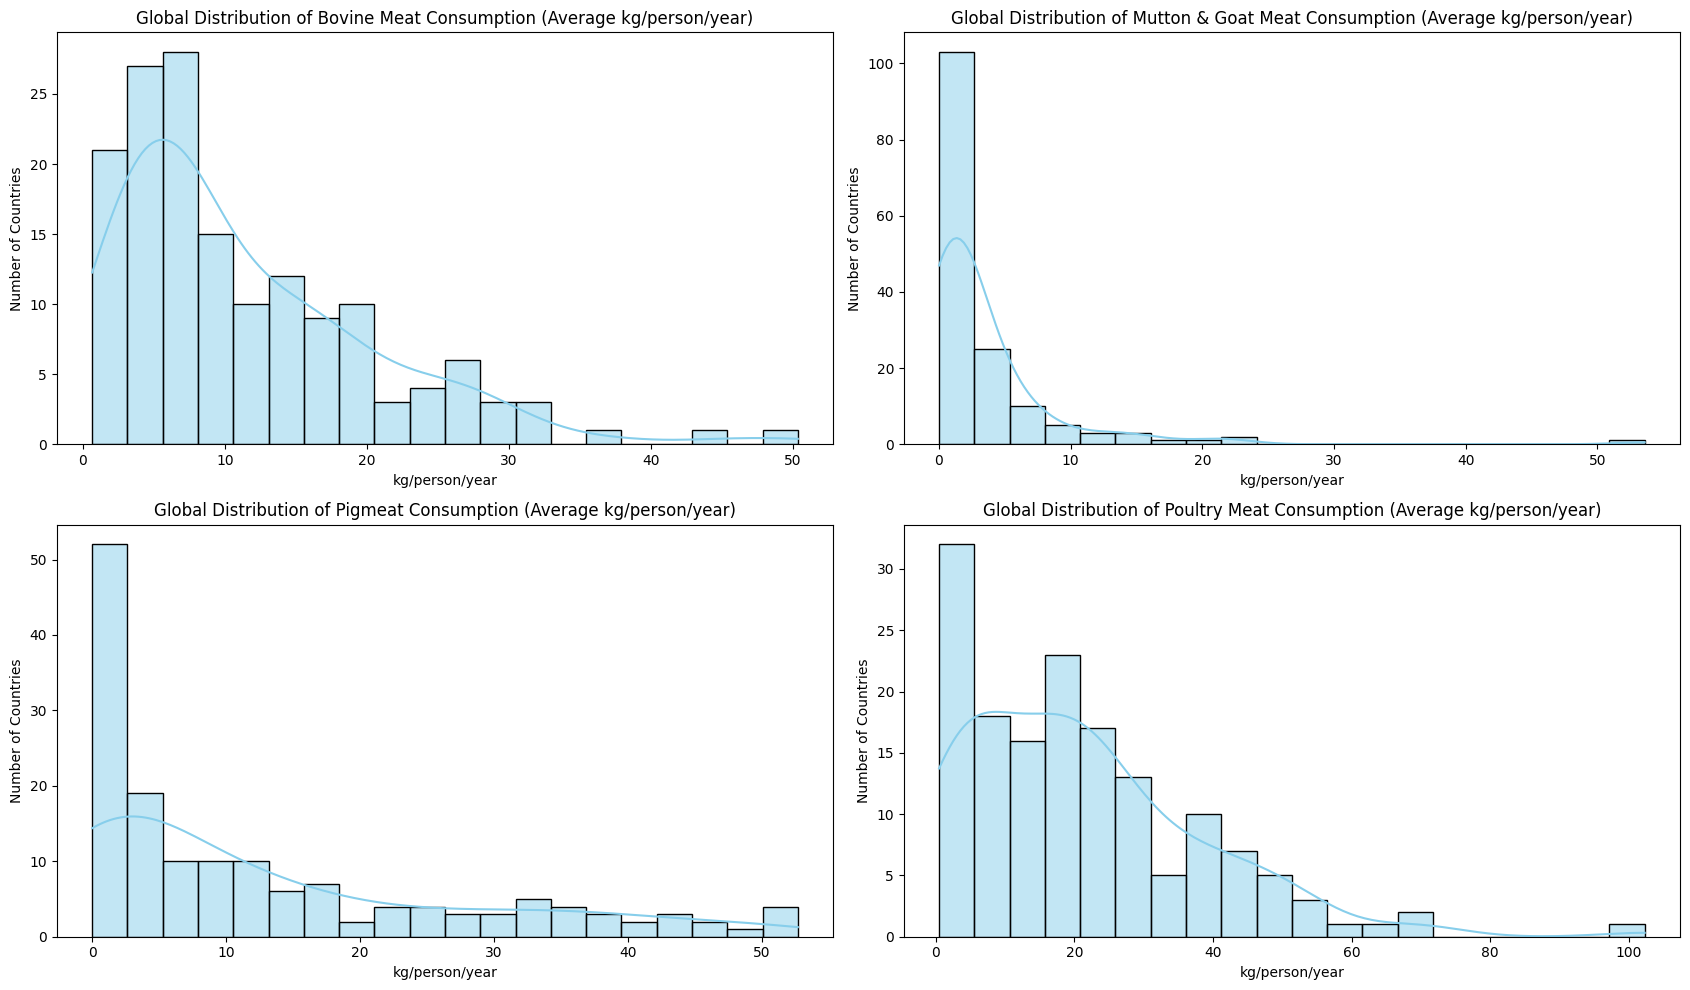

In [22]:
# Step 3: Checking the global distribution per meat type
# plot histograms in one figure with 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(17, 10))   
for ax, meat in zip(axes.flatten(), meat_columns):
    sns.histplot(meat_means_by_country[meat], bins=20, kde=True, color='skyblue', ax=ax)
    ax.set_title(f"Global Distribution of {meat} Consumption (Average kg/person/year)")
    ax.set_xlabel("kg/person/year")
    ax.set_ylabel("Number of Countries")
plt.tight_layout()
plt.show()  

Most countries exhibit low per-capita consumption levels, particularly for mutton & goat and pigmeat, while poultry consumption shows a broader distribution and higher typical values.

#### Smmary (Answer to Q2)

**<span style="color:#F4E6A1;"><strong>Summary</strong></span>** 

Across all meat categories, the countries with the highest per-capita consumption lie in the extreme right tail of the global distribution and represent a small subset of the total number of countries. As a result, they do not drive the overall global consumption pattern.

In contrast, the majority of countries cluster at low-to-moderate consumption levels for all meat types, particularly below approximately 10 kg/person/year. This indicates that global meat consumption patterns are shaped primarily by widespread moderate consumption rather than by a small number of high-consuming outliers.

**<span style="color:#F4E6A1;"><strong>Implication for modeling</strong></span>** 

The strong skewness and heterogeneity observed across meat-specific distributions suggest that modeling total meat consumption may benefit from treating individual meat types separately, or from applying transformations or robust methods to account for skewed and heterogeneous distributions across countries.


### 3. How has the global per capita meat consumption evolved from 2010 to 2022?

To estimate the global trend, we compute the yearly average of total per-capita meat consumption across countries (each country receives equal weight). We first build Total_meat as the sum of the four meat categories, then aggregate by year using a mean across countries.

In [41]:
# Step 1: Define "global". In here we need the total meat consumption between countries per year
master_file['Total_meat'] = (
    master_file['Bovine Meat'] +
    master_file['Pigmeat'] +
    master_file['Poultry Meat'] +
    master_file['Mutton & Goat Meat']
)   

print(master_file[['Country', 'Year', 'Total_meat']].head())

       Country  Year  Total_meat
0  Afghanistan  2010       12.07
1  Afghanistan  2011       11.38
2  Afghanistan  2012       11.48
3  Afghanistan  2013       11.49
4  Afghanistan  2014       12.19


In [44]:
# step 2: Add this to the master_file dataframe
global_avg = master_file.groupby('Year')['Total_meat'].mean().reset_index().rename(columns={'Total_meat': 'avg_meat'})  
print(global_avg.head(30))    


    Year   avg_meat
0   2010  45.374286
1   2011  45.680680
2   2012  45.682973
3   2013  45.743919
4   2014  45.875270
5   2015  46.467162
6   2016  46.770541
7   2017  47.151284
8   2018  48.253673
9   2019  49.871176
10  2020  48.836419
11  2021  50.184966
12  2022  50.161014


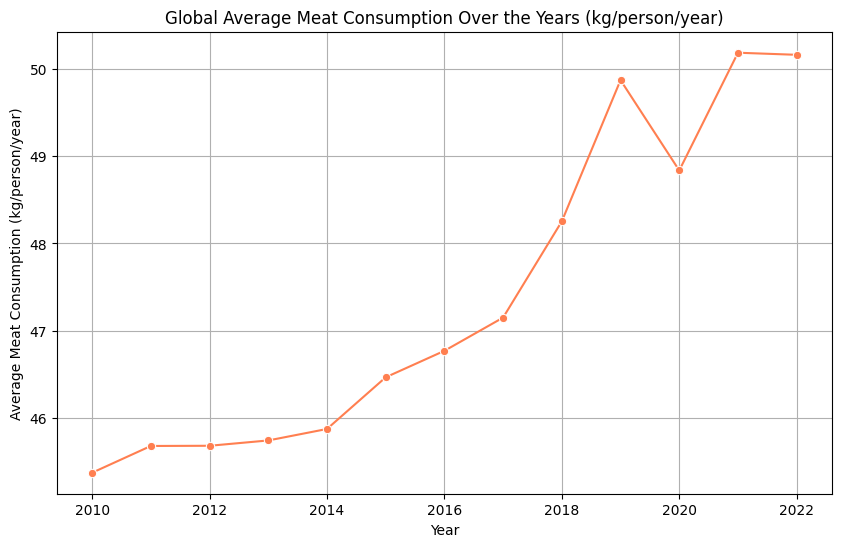

In [49]:
# step 3: plotting the global average meat consumption over the years
plt.figure(figsize=(10, 6))
sns.lineplot(data=global_avg, x='Year', y='avg_meat', marker='o', color='coral')
plt.title("Global Average Meat Consumption Over the Years (kg/person/year)")
plt.xlabel("Year")
plt.ylabel("Average Meat Consumption (kg/person/year)")
plt.grid()
plt.show()  


**<span style="color:#F4E6A1;"><strong>Note</strong></span>** 

The global trend is computed as the mean per-capita consumption across countries for each year. Error bars are not shown because each yearly value represents a single aggregated statistic rather than a distribution.

### 4. Which countries are in the top 5 for overall per capita meat

In [50]:
# Step one: For each country, calculate the total meat consumption at each year
master_file['Total_meat'] = (
    master_file['Bovine Meat'] +
    master_file['Pigmeat'] +
    master_file['Poultry Meat'] +
    master_file['Mutton & Goat Meat']
)
print(master_file[['Country', 'Year', 'Total_meat']].head())

       Country  Year  Total_meat
0  Afghanistan  2010       12.07
1  Afghanistan  2011       11.38
2  Afghanistan  2012       11.48
3  Afghanistan  2013       11.49
4  Afghanistan  2014       12.19


In [51]:
# Step 2: Compute the average the total meat consumption over years
avg_meat_by_country = master_file.groupby('Country')['Total_meat'].mean().reset_index().rename(columns={'Total_meat': 'avg_meat'})
print(avg_meat_by_country.head())

               Country   avg_meat
0          Afghanistan   9.845385
1              Albania  44.026154
2              Algeria  20.013846
3               Angola  24.759231
4  Antigua and Barbuda  86.189231


In [52]:
# step 3: Order by average meat consumption and extract top 10 countries
top_10_countries_avg = avg_meat_by_country.sort_values(by='avg_meat', ascending=False).head(10)
print("Top 10 countries by average meat consumption (kg/person/year):")
print(top_10_countries_avg)

Top 10 countries by average meat consumption (kg/person/year):
              Country    avg_meat
141             Tonga  156.772500
7           Australia  116.675385
100             Nauru  116.605000
5           Argentina  106.594615
69             Israel  106.176154
121             Samoa  103.849231
132             Spain   97.430769
20             Brazil   95.991538
50   French Polynesia   93.550000
117          Portugal   93.063077


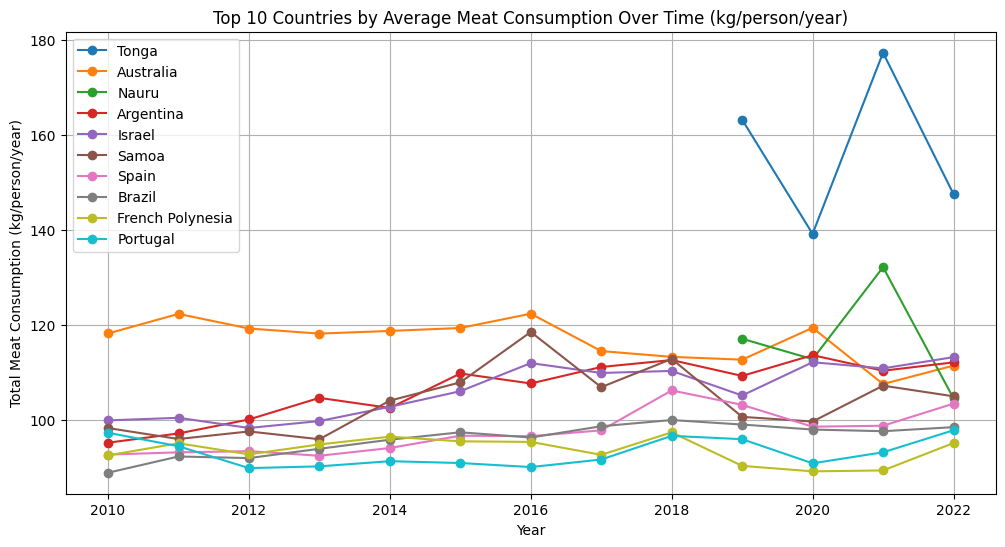

In [57]:
# plot top 10 countrys over time (add labels)
plt.figure(figsize=(12, 6))
for country in top_10_countries_avg['Country']:
    country_data = master_file[master_file['Country'] == country]
    plt.plot(country_data['Year'], country_data['Total_meat'], marker='o', label=country)   
plt.title("Top 10 Countries by Average Meat Consumption Over Time (kg/person/year)")
plt.xlabel("Year")
plt.ylabel("Total Meat Consumption (kg/person/year)")
plt.legend()
plt.grid()
plt.show()

#### Smmary (Answer to Q4)

**<span style="color:#F4E6A1;"><strong>Summary (Answer to Q4)</strong></span>**

To identify the highest overall meat consumers, we computed `Total_meat` as the sum of bovine, pigmeat, poultry, and mutton & goat consumption (kg/person/year), and then averaged this total per country over the 2010–2022 period. The top 5 countries correspond to the upper extreme of the global distribution, showing consistently high per-capita intake across the years for which data are available.

**<span style="color:#F4E6A1;"><strong>Outlier note</strong></span>**

Tonga stands out as an extreme outlier, with substantially higher per-capita total meat consumption than the rest of the top-consuming countries. Tonga is retained in the dataset as a valid observation, but it can distort visual comparisons by stretching the y-axis and compressing the variability of other countries. For readability, some comparative plots may exclude Tonga or show it separately, while keeping it included in the underlying analysis.

**<span style="color:#F4E6A1;"><strong>Data coverage note</strong></span>**

Although Tonga ranks among the highest overall per-capita meat consumers, its time series exhibits substantial gaps in data availability, particularly during the earlier years of the 2010–2022 period. As a result, Tonga’s average consumption and temporal trajectory are not directly comparable to countries with complete yearly coverage.

Tonga is retained in the dataset as a valid high-consumption case, but its incomplete time coverage is explicitly acknowledged, and it is treated with caution in time-based comparisons and modeling analyses.

**<span style="color:#F4E6A1;"><strong>Implication for modeling</strong></span>**

Because the target distribution includes extreme high-consuming countries and heterogeneous temporal coverage, downstream models may benefit from robust evaluation (e.g., comparing performance with and without extreme outliers) and/or target transformations to reduce sensitivity to the right tail.



### 5.  Which countries represent the modal range of global per-capita meat consumption?

In [80]:
# Data
values = avg_meat_by_country['avg_meat']

# --- Step 1: histogram to get the modal bin ---
counts, bin_edges = np.histogram(values, bins=20)

modal_bin_index = np.argmax(counts)
modal_min = bin_edges[modal_bin_index]
modal_max = bin_edges[modal_bin_index + 1]

print(f"Modal range (bin with highest frequency): "
      f"{modal_min:.2f} – {modal_max:.2f} kg/person/year")




Modal range (bin with highest frequency): 10.48 – 18.18 kg/person/year


In [81]:
# --- Step 2: countries in the modal range ---
modal_countries = avg_meat_by_country[
    (avg_meat_by_country['avg_meat'] >= modal_min) &
    (avg_meat_by_country['avg_meat'] < modal_max)
].sort_values('avg_meat')

print(f"\nNumber of countries in the modal range: {len(modal_countries)}")
display(modal_countries[['Country', 'avg_meat']].head(10))


Number of countries in the modal range: 21


,Country,avg_meat
146,Uganda,10.680000
140,Togo,11.242308
58,Guinea,11.835385
54,Ghana,11.970769
80,Lesotho,12.160000
75,Kenya,12.410000
24,Cambodia,12.910000
66,Indonesia,13.630769
101,Nepal,13.991538
17,Bhutan,14.007500


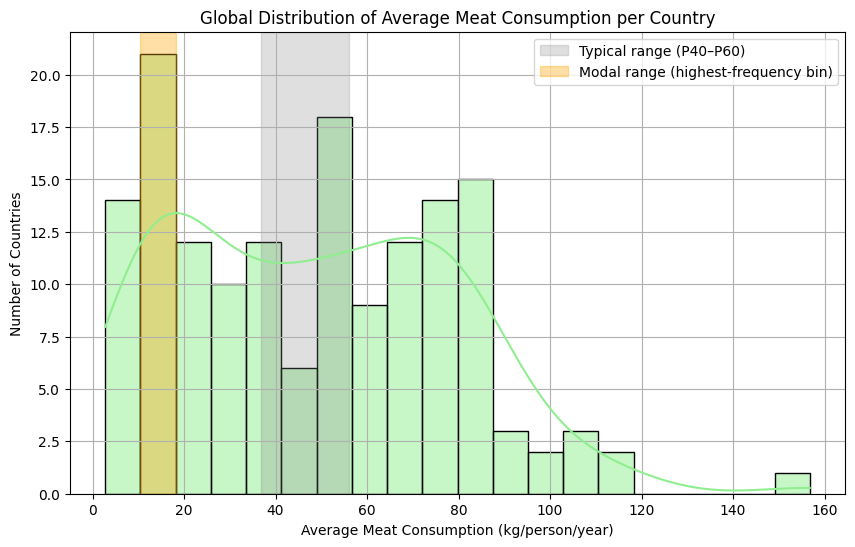

In [82]:
plt.figure(figsize=(10, 6))

# Histogram + KDE
sns.histplot(
    values,
    bins=20,
    kde=True,
    color='lightgreen'
)

# Typical range (NOT the mode, just reference)
plt.axvspan(
    values.quantile(0.40),
    values.quantile(0.60),
    alpha=0.25,
    color='gray',
    label='Typical range (P40–P60)'
)

# Modal range (THIS is the mode)
plt.axvspan(
    modal_min,
    modal_max,
    alpha=0.35,
    color='orange',
    label='Modal range (highest-frequency bin)'
)

plt.title("Global Distribution of Average Meat Consumption per Country")
plt.xlabel("Average Meat Consumption (kg/person/year)")
plt.ylabel("Number of Countries")
plt.legend()
plt.grid()
plt.show()
